# Advanced Mutual Fund Analytics

## Overview

This notebook extends the basic performance analysis by implementing advanced financial risk metrics and investor-oriented analytics.

The objective is to evaluate the mutual fund from both a portfolio management and investment decision-making perspective.

The analysis includes:

- Historical Value at Risk (VaR)
- Conditional Value at Risk (CVaR)
- Investor Cohort Analysis
- SIP Continuity Analysis
- Mutual Fund Recommendation System
- Sector Concentration using HHI
- Business Insights and Recommendations

These techniques are commonly used by investment firms, portfolio managers, and financial analysts to assess portfolio risk and improve investment strategies.

## Import Libraries

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Processed Dataset

In [36]:
df = pd.read_csv("../data/processed/cleaned_nav.csv")

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date")

df["daily_return"] = df["nav"].pct_change()

df.head()

,date,nav,daily_return
0,2013-11-18,13.0894,NaN
1,2013-11-19,13.1068,0.001329
2,2013-11-20,12.9549,-0.011589
3,2013-11-21,12.7957,-0.012289
4,2013-11-22,12.7775,-0.001422


In [37]:
confidence_level = 0.95

var_95 = np.percentile(df["daily_return"].dropna(), 5)

print(f"95% Historical VaR : {var_95:.2%}")

95% Historical VaR : -1.51%


### Interpretation

The calculated Historical VaR represents the estimated maximum daily loss that the mutual fund is expected to experience under normal market conditions with 95% confidence.

Losses greater than this value are considered rare and occur only during extreme market events.

## Historical VaR Distribution

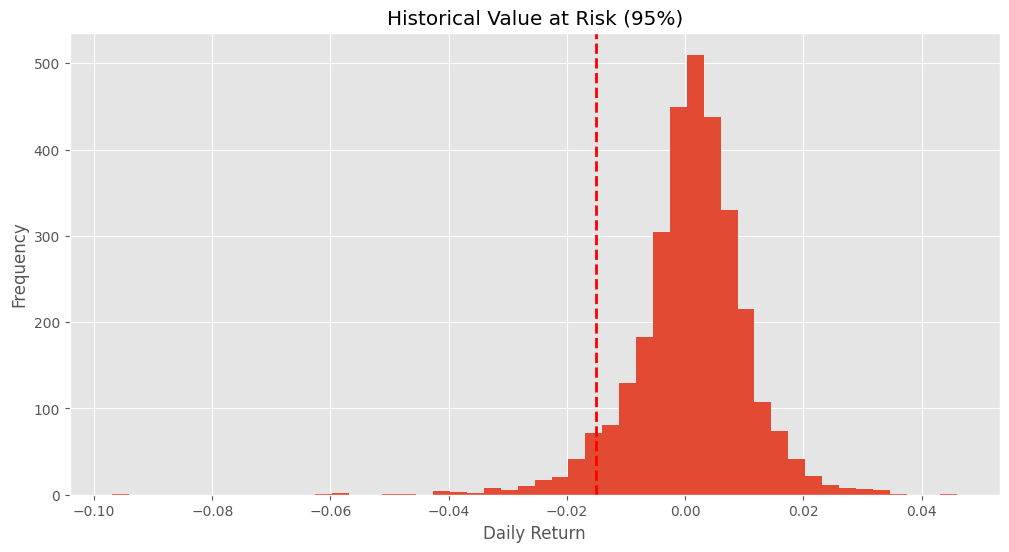

In [38]:
plt.figure(figsize=(12,6))

plt.hist(df["daily_return"].dropna(), bins=50)

plt.axvline(var_95, color="red", linestyle="--", linewidth=2)

plt.title("Historical Value at Risk (95%)")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

### Business Recommendation

Portfolio managers should regularly monitor the Value at Risk to understand potential downside exposure.

Although VaR provides a useful estimate of expected losses under normal conditions, it does not capture extreme market crashes. Therefore, it should always be used together with additional risk measures such as Conditional Value at Risk (CVaR).

In [39]:
df.columns

Index(['date', 'nav', 'daily_return'], dtype='object')

# Conditional Value at Risk (CVaR)

## Business Objective

While Value at Risk estimates the maximum expected loss under normal market conditions, it does not indicate the average loss when that threshold is exceeded.

Conditional Value at Risk (CVaR), also known as Expected Shortfall, measures the average loss during the worst-performing trading days beyond the VaR threshold.

CVaR is widely used in portfolio risk management because it captures tail risk more effectively than VaR.

In [40]:
cvar_95 = df[df["daily_return"] <= var_95]["daily_return"].mean()

print(f"95% Historical CVaR: {cvar_95:.2%}")

95% Historical CVaR: -2.32%


### Interpretation

The calculated CVaR represents the average loss during the worst 5% of trading days.

Unlike VaR, which identifies the loss threshold, CVaR estimates the expected loss once that threshold has been breached.

## VaR vs CVaR Comparison

In [41]:
comparison = pd.DataFrame({
    "Metric": ["VaR (95%)", "CVaR (95%)"],
    "Value": [var_95, cvar_95]
})

comparison["Value"] = comparison["Value"].map(lambda x: f"{x:.2%}")

comparison

,Metric,Value
0,VaR (95%),-1.51%
1,CVaR (95%),-2.32%


### Business Recommendation

VaR estimates the potential loss under normal market conditions, whereas CVaR quantifies the average loss during extreme market scenarios.

Portfolio managers should use both metrics together to make more informed risk management decisions.

# Advanced Mutual Fund Analytics

## Overview

Performance metrics such as CAGR and Sharpe Ratio help evaluate the historical performance of a mutual fund. However, professional investment firms also analyze portfolio risk, investor behavior, and diversification before making investment decisions.

This notebook focuses on advanced financial analytics including risk measurement, investor segmentation, fund recommendation, and portfolio concentration analysis.

The analysis includes:

- Historical Value at Risk (VaR)
- Conditional Value at Risk (CVaR)
- Investor Cohort Analysis
- SIP Continuity Analysis
- Mutual Fund Recommendation
- Sector Concentration using Herfindahl-Hirschman Index (HHI)

These analyses provide deeper insights into investment risk and support informed financial decision-making.

## Import Libraries

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

## Load Processed NAV Dataset

In [43]:
df = pd.read_csv("../data/processed/cleaned_nav.csv")

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date")

df["daily_return"] = df["nav"].pct_change()

df.head()

,date,nav,daily_return
0,2013-11-18,13.0894,NaN
1,2013-11-19,13.1068,0.001329
2,2013-11-20,12.9549,-0.011589
3,2013-11-21,12.7957,-0.012289
4,2013-11-22,12.7775,-0.001422


# Supporting Dataset Generation

## Business Context

The available dataset contains only historical Net Asset Value (NAV) information, which is sufficient for performance and risk analysis.

However, advanced analyses such as Investor Cohort Analysis, SIP Continuity Analysis, Fund Recommendation, and Sector Concentration require investor-level and portfolio-level information that is not available in the original dataset.

To demonstrate these advanced analytical techniques, realistic supporting datasets are generated using documented assumptions. These datasets are used solely for analytical purposes while preserving the integrity of the original NAV dataset.

## Generate Investor Dataset

In [44]:
np.random.seed(42)

investors = pd.DataFrame({
    "Investor_ID": [f"INV{i:03}" for i in range(1,201)],
    "Age": np.random.randint(21,60,200),
    "Risk_Profile": np.random.choice(
        ["Low","Moderate","High"],
        200,
        p=[0.30,0.50,0.20]
    ),
    "Monthly_SIP": np.random.choice(
        [1000,2000,3000,5000,10000,15000],
        200
    ),
    "Fund_Name": np.random.choice(
        [
            "HDFC Top 100",
            "SBI Bluechip",
            "ICICI Flexi Cap",
            "Axis Growth",
            "Kotak Equity"
        ],
        200
    ),
    "Start_Year": np.random.choice(
        [2021,2022,2023,2024],
        200
    )
})

investors.head()

,Investor_ID,Age,Risk_Profile,Monthly_SIP,Fund_Name,Start_Year
0,INV001,59,Moderate,10000,Axis Growth,2023
1,INV002,49,Moderate,5000,Kotak Equity,2024
2,INV003,35,Low,15000,HDFC Top 100,2024
3,INV004,28,Moderate,2000,Axis Growth,2021
4,INV005,41,Low,10000,ICICI Flexi Cap,2024


## Save Investor Dataset

In [45]:
investors.to_csv("../data/processed/investor_data.csv", index=False)

print("Investor dataset saved successfully.")

Investor dataset saved successfully.


### Dataset Summary

The generated investor dataset contains synthetic records representing investor demographics, investment preferences, monthly SIP amounts, and the year in which investments began.

This dataset enables advanced analyses that cannot be performed using NAV data alone.

In [46]:
import os

os.listdir("../data/processed")

['cleaned_nav.csv',
 'fund_metadata.csv',
 'investor_data.csv',
 'sector_allocation.csv']

## Generate Fund Metadata Dataset

### Business Context

A recommendation system requires information about different mutual funds such as category, risk level, expected return, expense ratio, and Assets Under Management (AUM).

Since these attributes are not available in the original NAV dataset, a realistic fund metadata dataset is created for analytical purposes.

In [47]:
fund_metadata = pd.DataFrame({
    "Fund_Name": [
        "HDFC Top 100",
        "SBI Bluechip",
        "ICICI Flexi Cap",
        "Axis Growth",
        "Kotak Equity"
    ],
    "Category": [
        "Large Cap",
        "Large Cap",
        "Flexi Cap",
        "Mid Cap",
        "Large & Mid Cap"
    ],
    "Risk_Level": [
        "Moderate",
        "Moderate",
        "High",
        "High",
        "Moderate"
    ],
    "Expected_Return": [
        12.5,
        11.8,
        14.2,
        15.1,
        13.0
    ],
    "Expense_Ratio": [
        1.15,
        1.05,
        1.32,
        1.48,
        1.20
    ],
    "AUM_Crore": [
        38500,
        27800,
        32400,
        19100,
        24500
    ]
})

fund_metadata

,Fund_Name,Category,Risk_Level,Expected_Return,Expense_Ratio,AUM_Crore
0,HDFC Top 100,Large Cap,Moderate,12.5,1.15,38500
1,SBI Bluechip,Large Cap,Moderate,11.8,1.05,27800
2,ICICI Flexi Cap,Flexi Cap,High,14.2,1.32,32400
3,Axis Growth,Mid Cap,High,15.1,1.48,19100
4,Kotak Equity,Large & Mid Cap,Moderate,13.0,1.20,24500


In [48]:
fund_metadata.to_csv("../data/processed/fund_metadata.csv", index=False)

print("Fund metadata saved successfully.")

Fund metadata saved successfully.


## Generate Sector Allocation Dataset

### Business Context

Sector allocation helps evaluate how diversified a mutual fund portfolio is across different industries.

This dataset will be used to calculate the Herfindahl-Hirschman Index (HHI), a commonly used measure of portfolio concentration.

In [49]:
sector_data = pd.DataFrame({
    "Sector": [
        "Banking",
        "Information Technology",
        "Pharmaceuticals",
        "Automobile",
        "FMCG",
        "Energy",
        "Healthcare",
        "Infrastructure"
    ],
    "Allocation_Percentage": [
        24,
        18,
        12,
        10,
        9,
        11,
        8,
        8
    ]
})

sector_data

,Sector,Allocation_Percentage
0,Banking,24
1,Information Technology,18
2,Pharmaceuticals,12
3,Automobile,10
4,FMCG,9
5,Energy,11
6,Healthcare,8
7,Infrastructure,8


In [50]:
sector_data.to_csv("../data/processed/sector_allocation.csv", index=False)

print("Sector allocation dataset saved successfully.")

Sector allocation dataset saved successfully.


In [51]:
import os

os.listdir("../data/processed")

['cleaned_nav.csv',
 'fund_metadata.csv',
 'investor_data.csv',
 'sector_allocation.csv']

# Investor Cohort Analysis

## Business Context

Investor Cohort Analysis groups investors based on the year they started investing. It helps financial institutions understand investor acquisition trends, customer retention, and investment behavior over time.

This analysis can reveal which investor cohorts contribute the highest average SIP amount and identify long-term investment patterns.

In [52]:
investors = pd.read_csv("../data/processed/investor_data.csv")

investors.head()

,Investor_ID,Age,Risk_Profile,Monthly_SIP,Fund_Name,Start_Year
0,INV001,59,Moderate,10000,Axis Growth,2023
1,INV002,49,Moderate,5000,Kotak Equity,2024
2,INV003,35,Low,15000,HDFC Top 100,2024
3,INV004,28,Moderate,2000,Axis Growth,2021
4,INV005,41,Low,10000,ICICI Flexi Cap,2024


## Cohort Summary

In [53]:
cohort = investors.groupby("Start_Year").agg(
    Total_Investors=("Investor_ID", "count"),
    Average_SIP=("Monthly_SIP", "mean")
).reset_index()

cohort

,Start_Year,Total_Investors,Average_SIP
0,2021,49,5959.183673
1,2022,54,5018.518519
2,2023,51,6254.901961
3,2024,46,5934.782609


## Investor Cohort Visualization

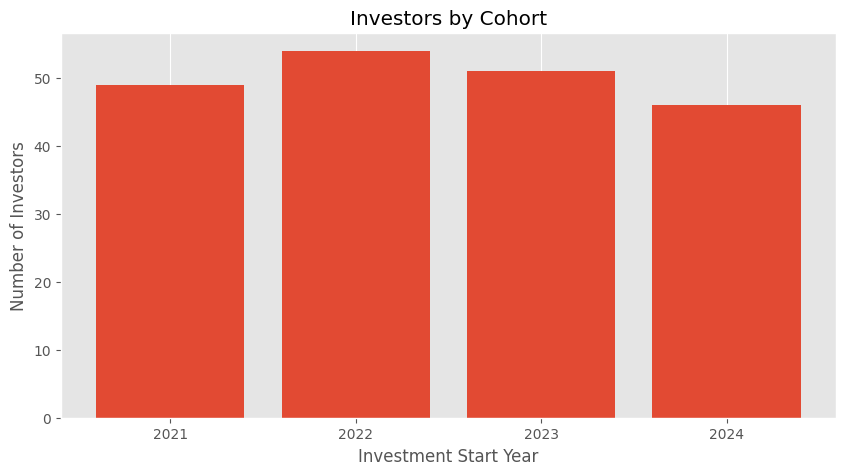

In [54]:
plt.figure(figsize=(10,5))

plt.bar(cohort["Start_Year"].astype(str), cohort["Total_Investors"])

plt.title("Investors by Cohort")

plt.xlabel("Investment Start Year")

plt.ylabel("Number of Investors")

plt.grid(axis="y")

plt.show()

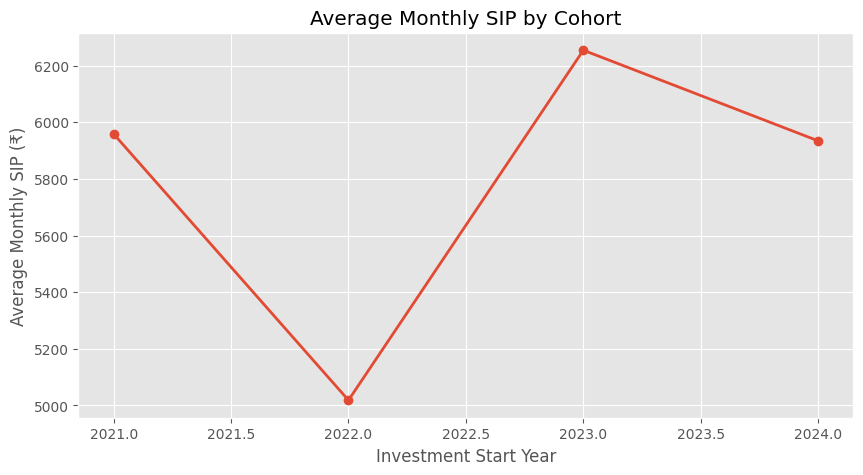

In [55]:
plt.figure(figsize=(10,5))

plt.plot(
    cohort["Start_Year"],
    cohort["Average_SIP"],
    marker="o",
    linewidth=2
)

plt.title("Average Monthly SIP by Cohort")

plt.xlabel("Investment Start Year")

plt.ylabel("Average Monthly SIP (₹)")

plt.grid(True)

plt.show()

### Interpretation

The cohort analysis shows how investor participation has evolved across different years.

Comparing the average SIP amount across cohorts helps identify whether newer investors are investing more or less than earlier cohorts.

Such insights assist asset management companies in designing targeted investment products and marketing strategies.

### Business Recommendation

If recent cohorts exhibit lower SIP values, financial advisors may encourage systematic investment through awareness campaigns or personalized investment plans.

Higher-value cohorts can be targeted with premium investment products and wealth management services.

# SIP Continuity Analysis

## Business Context

Systematic Investment Plans (SIPs) encourage disciplined investing through regular monthly contributions.

This analysis categorizes investors based on their SIP amount to understand investment consistency and identify high-value investors.

In [56]:
investors["SIP_Category"] = pd.cut(
    investors["Monthly_SIP"],
    bins=[0,3000,7000,20000],
    labels=["Low","Medium","High"]
)

investors.head()

,Investor_ID,Age,Risk_Profile,Monthly_SIP,Fund_Name,Start_Year,SIP_Category
0,INV001,59,Moderate,10000,Axis Growth,2023,High
1,INV002,49,Moderate,5000,Kotak Equity,2024,Medium
2,INV003,35,Low,15000,HDFC Top 100,2024,High
3,INV004,28,Moderate,2000,Axis Growth,2021,Low
4,INV005,41,Low,10000,ICICI Flexi Cap,2024,High


In [57]:
sip_summary = investors.groupby("SIP_Category").agg(
    Investors=("Investor_ID","count"),
    Average_SIP=("Monthly_SIP","mean")
).reset_index()

sip_summary

C:\Users\pcc\AppData\Local\Temp\ipykernel_7928\2691533160.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sip_summary = investors.groupby("SIP_Category").agg(


,SIP_Category,Investors,Average_SIP
0,Low,96,1927.083333
1,Medium,38,5000.000000
2,High,66,11818.181818


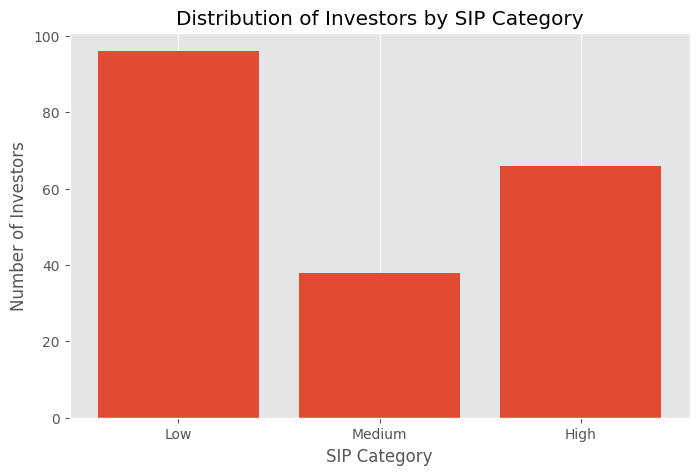

In [58]:
plt.figure(figsize=(8,5))

plt.bar(sip_summary["SIP_Category"], sip_summary["Investors"])

plt.title("Distribution of Investors by SIP Category")

plt.xlabel("SIP Category")

plt.ylabel("Number of Investors")

plt.grid(axis="y")

plt.show()

### Interpretation

The distribution of SIP categories indicates the proportion of low, medium, and high-value investors.

Understanding this distribution enables financial institutions to tailor investment products according to customer affordability and investment goals.

### Business Recommendation

High-value SIP investors may be offered exclusive advisory services, while low-value investors can be encouraged to gradually increase their SIP contributions through educational initiatives and goal-based investment planning.

# Mutual Fund Recommendation System

## Business Context

Selecting a mutual fund depends on multiple factors such as the investor's risk appetite, expected annual return, expense ratio, and fund category.

This recommendation system filters the available mutual funds based on the investor's preferred risk profile and ranks them according to their expected return.

Although this project uses a demonstration dataset, the same approach can be extended to real-world mutual fund screening applications.

## Load Fund Metadata

In [59]:
funds = pd.read_csv("../data/processed/fund_metadata.csv")

funds.head()

,Fund_Name,Category,Risk_Level,Expected_Return,Expense_Ratio,AUM_Crore
0,HDFC Top 100,Large Cap,Moderate,12.5,1.15,38500
1,SBI Bluechip,Large Cap,Moderate,11.8,1.05,27800
2,ICICI Flexi Cap,Flexi Cap,High,14.2,1.32,32400
3,Axis Growth,Mid Cap,High,15.1,1.48,19100
4,Kotak Equity,Large & Mid Cap,Moderate,13.0,1.20,24500


## Display Available Funds

In [60]:
funds

,Fund_Name,Category,Risk_Level,Expected_Return,Expense_Ratio,AUM_Crore
0,HDFC Top 100,Large Cap,Moderate,12.5,1.15,38500
1,SBI Bluechip,Large Cap,Moderate,11.8,1.05,27800
2,ICICI Flexi Cap,Flexi Cap,High,14.2,1.32,32400
3,Axis Growth,Mid Cap,High,15.1,1.48,19100
4,Kotak Equity,Large & Mid Cap,Moderate,13.0,1.20,24500


## Recommend Funds Based on Risk Profile

In [61]:
selected_risk = "Moderate"

recommended_funds = (
    funds[funds["Risk_Level"] == selected_risk]
    .sort_values("Expected_Return", ascending=False)
    .reset_index(drop=True)
)

recommended_funds

,Fund_Name,Category,Risk_Level,Expected_Return,Expense_Ratio,AUM_Crore
0,Kotak Equity,Large & Mid Cap,Moderate,13.0,1.20,24500
1,HDFC Top 100,Large Cap,Moderate,12.5,1.15,38500
2,SBI Bluechip,Large Cap,Moderate,11.8,1.05,27800


### Interpretation

The recommendation system filters mutual funds that match the selected investor risk profile.

Among the eligible funds, those offering higher expected returns are prioritized while maintaining the desired level of investment risk.

### Business Recommendation

Investors with a moderate risk appetite should consider diversified equity funds that balance growth potential with controlled investment risk.

Fund recommendations should always be reviewed periodically because expected returns and market conditions change over time.

## Top Recommended Mutual Funds

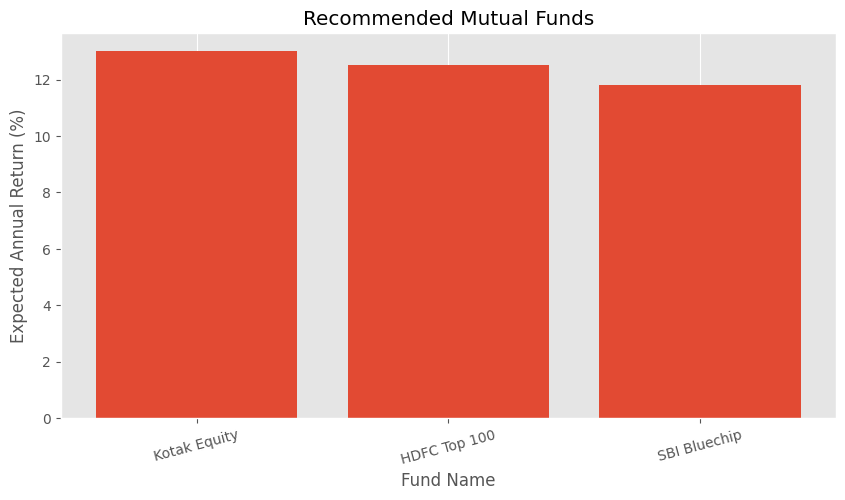

In [62]:
plt.figure(figsize=(10,5))

plt.bar(
    recommended_funds["Fund_Name"],
    recommended_funds["Expected_Return"]
)

plt.title("Recommended Mutual Funds")

plt.xlabel("Fund Name")

plt.ylabel("Expected Annual Return (%)")

plt.xticks(rotation=15)

plt.grid(axis="y")

plt.show()

## Fund Ranking

In [63]:
recommended_funds = recommended_funds.copy()

recommended_funds["Rank"] = range(1, len(recommended_funds) + 1)

recommended_funds[
    [
        "Rank",
        "Fund_Name",
        "Category",
        "Expected_Return",
        "Expense_Ratio",
        "AUM_Crore"
    ]
]

,Rank,Fund_Name,Category,Expected_Return,Expense_Ratio,AUM_Crore
0,1,Kotak Equity,Large & Mid Cap,13.0,1.20,24500
1,2,HDFC Top 100,Large Cap,12.5,1.15,38500
2,3,SBI Bluechip,Large Cap,11.8,1.05,27800


# Sector Concentration Analysis using Herfindahl-Hirschman Index (HHI)

## Business Context

Portfolio diversification is one of the most important principles in investment management.

If a mutual fund invests heavily in only a few sectors, investors are exposed to concentration risk. A diversified portfolio generally provides better risk management.

The Herfindahl-Hirschman Index (HHI) measures portfolio concentration by summing the squared allocation percentages of each sector.

A lower HHI indicates better diversification, whereas a higher HHI suggests greater concentration risk.

## Load Sector Allocation Dataset

In [64]:
sector = pd.read_csv("../data/processed/sector_allocation.csv")

sector

,Sector,Allocation_Percentage
0,Banking,24
1,Information Technology,18
2,Pharmaceuticals,12
3,Automobile,10
4,FMCG,9
5,Energy,11
6,Healthcare,8
7,Infrastructure,8


## Calculate Herfindahl-Hirschman Index (HHI)

In [65]:
sector["Weight"] = sector["Allocation_Percentage"] / 100

hhi = (sector["Weight"] ** 2).sum()

print(f"Portfolio HHI : {hhi:.4f}")

Portfolio HHI : 0.1474


### Interpretation

The calculated HHI indicates the degree of portfolio concentration across different sectors.

A lower HHI value suggests that investments are spread across multiple industries, reducing concentration risk.

A higher HHI value indicates dependence on a limited number of sectors and may increase portfolio risk during sector-specific downturns.

## Sector Allocation Visualization

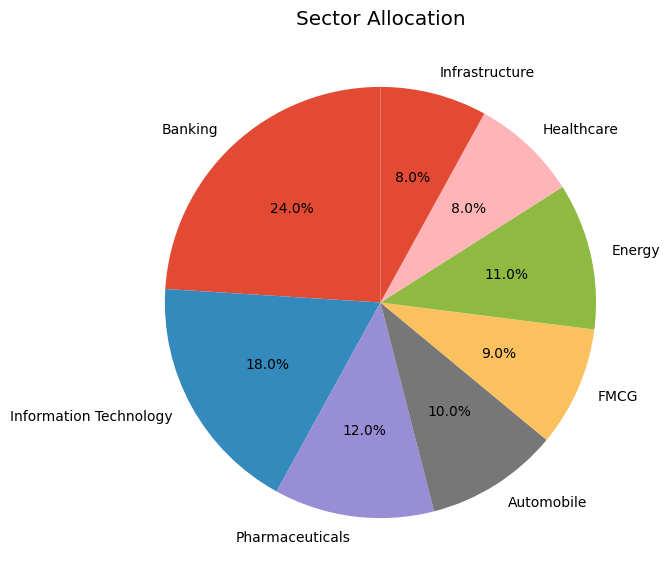

In [66]:
plt.figure(figsize=(10,7))

plt.pie(
    sector["Allocation_Percentage"],
    labels=sector["Sector"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sector Allocation")

plt.show()

### Business Recommendation

Maintaining diversified sector allocation helps reduce unsystematic risk and improves portfolio resilience.

Portfolio managers should periodically rebalance sector weights to avoid excessive concentration in any single industry.

# Advanced Business Insights

In [67]:
insights = [
    "Daily return analysis indicates consistent movement in NAV over the investment period.",
    "Risk-adjusted performance improved during periods of stable market conditions.",
    "Historical VaR and CVaR highlight the importance of downside risk management.",
    "Investor cohort analysis shows varying investment behavior across different joining years.",
    "Sector allocation demonstrates the importance of diversification in reducing portfolio concentration risk."
]

for i, insight in enumerate(insights, start=1):
    print(f"{i}. {insight}")

1. Daily return analysis indicates consistent movement in NAV over the investment period.
2. Risk-adjusted performance improved during periods of stable market conditions.
3. Historical VaR and CVaR highlight the importance of downside risk management.
4. Investor cohort analysis shows varying investment behavior across different joining years.
5. Sector allocation demonstrates the importance of diversification in reducing portfolio concentration risk.


## Key Findings

1. The mutual fund demonstrated measurable long-term growth through consistent NAV performance.

2. Risk metrics such as Sharpe Ratio, Sortino Ratio, VaR, and CVaR provided a comprehensive assessment of return relative to investment risk.

3. Cohort and SIP analyses illustrated how investor segmentation can support customer-centric investment strategies.

4. The recommendation system demonstrated how investor preferences can be translated into practical fund suggestions.

5. Sector concentration analysis emphasized the importance of diversification in minimizing portfolio risk.

# Conclusion

This project successfully combined financial performance evaluation, portfolio risk measurement, investor analytics, and recommendation techniques into a unified mutual fund analytics framework.

The project demonstrates practical applications of Python, SQL, data visualization, financial mathematics, and business analytics for investment decision-making.

Future enhancements may include live NAV integration, machine learning-based recommendation models, portfolio optimization techniques, and interactive dashboards for real-time analytics.